# Polinomial Models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [2]:
# Sample dataset
data = {
    'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Exam_Score': [50, 65, 75, 80, 85, 88, 89, 88, 85, 80]
}

df = pd.DataFrame(data)
df.head()

,Study_Hours,Exam_Score
0,1,50
1,2,65
2,3,75
3,4,80
4,5,85


In [3]:
# Extract features and target
X = df[['Study_Hours']]
y = df['Exam_Score']

In [4]:
# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Predicciones lineales
y_pred_lin = lin_reg.predict(X)

In [5]:
# Fit polynomial regression
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

# Predicción polinomial
y_pred_poly = poly_reg.predict(X_poly)

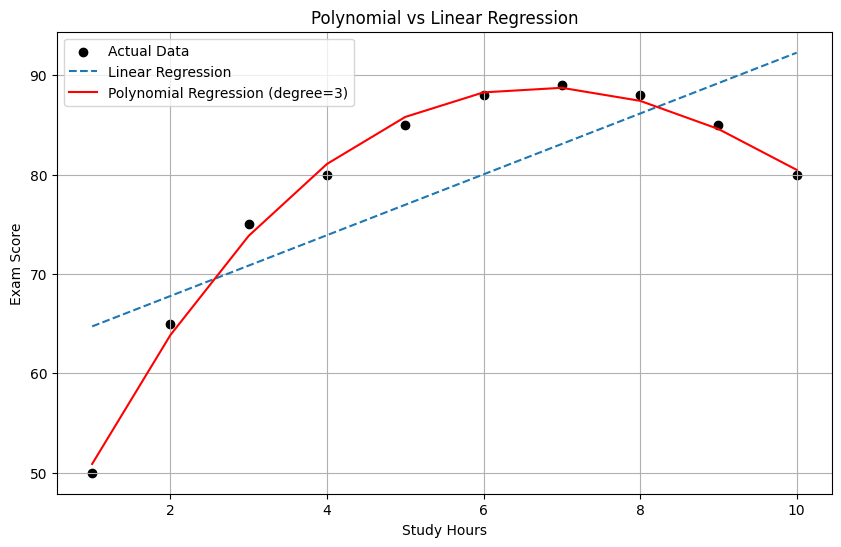

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Actual Data", color='black')

plt.plot(X, y_pred_lin, label="Linear Regression", linestyle='--')
plt.plot(X, y_pred_poly, label=f"Polynomial Regression (degree={degree})", color='red')

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Polynomial vs Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
mse_lin = mean_squared_error(y, y_pred_lin)
mse_poly = mean_squared_error(y, y_pred_poly)

print("Linear MSE:", mse_lin)
print("Polynomial MSE:", mse_poly)

Linear MSE: 61.369696969696975
Polynomial MSE: 0.6102564102564141


In [8]:
coefs = poly_reg.coef_
intercept = poly_reg.intercept_

equation = f"y = {intercept:.3f}"
for i, c in enumerate(coefs[1:], start=1):
    equation += f" + ({c:.3f})x^{i}"

print("Polynomial equation:")
print(equation)

Polynomial equation:
y = 34.667 + (17.915)x^1 + (-1.741)x^2 + (0.041)x^3


# Exponential regression

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [10]:
data = {
    'Date': pd.date_range(start='2022-01-01', periods=10),
    'Engaged_Users': [100, 150, 225, 338, 507, 761, 1142, 1713, 2570, 3855]
}

df = pd.DataFrame(data)
df

,Date,Engaged_Users
0,2022-01-01,100
1,2022-01-02,150
2,2022-01-03,225
3,2022-01-04,338
4,2022-01-05,507
5,2022-01-06,761
6,2022-01-07,1142
7,2022-01-08,1713
8,2022-01-09,2570
9,2022-01-10,3855


In [11]:
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

X = df[['Days']]
y = df['Engaged_Users']

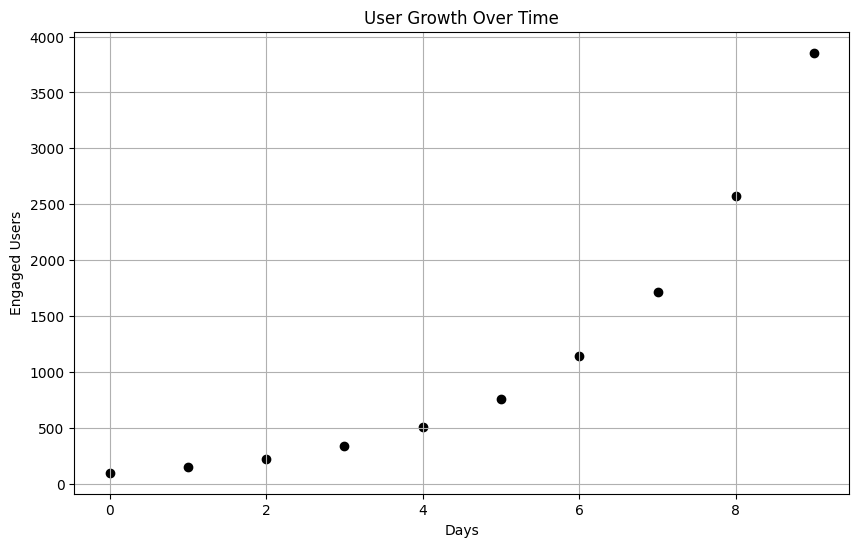

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black')
plt.xlabel("Days")
plt.ylabel("Engaged Users")
plt.title("User Growth Over Time")
plt.grid(True)
plt.show()

In [13]:
lin = LinearRegression()
lin.fit(X, y)
y_pred_lin = lin.predict(X)

In [14]:
y_log = np.log(y)

exp_model = LinearRegression()
exp_model.fit(X, y_log)

# Predicción transformada
y_pred_exp = np.exp(exp_model.predict(X))

In [15]:
from sklearn.metrics import mean_squared_error

mse_lin = mean_squared_error(y, y_pred_lin)
mse_exp = mean_squared_error(y, y_pred_exp)

print("Linear MSE:", mse_lin)
print("Exponential MSE:", mse_exp)

Linear MSE: 261371.25333333333
Exponential MSE: 0.3845637617704857


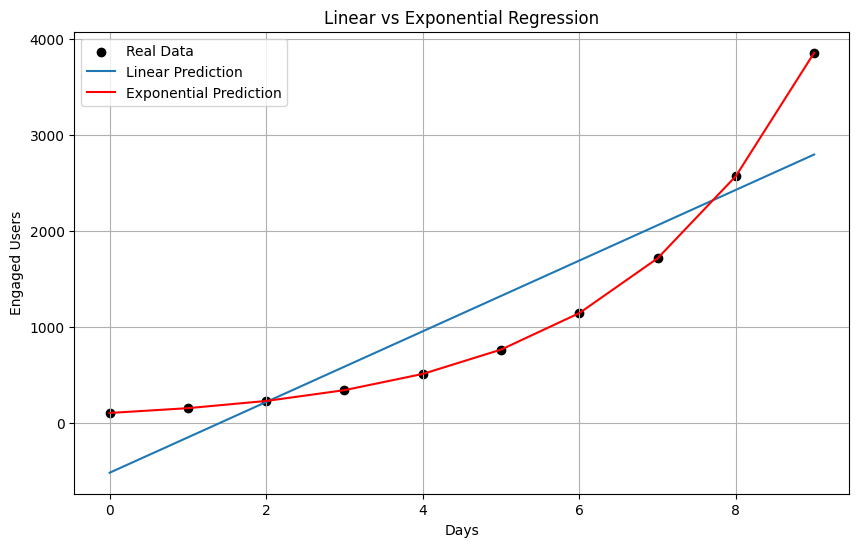

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Real Data", color='black')
plt.plot(X, y_pred_lin, label="Linear Prediction")
plt.plot(X, y_pred_exp, label="Exponential Prediction", color='red')

plt.xlabel("Days")
plt.ylabel("Engaged Users")
plt.title("Linear vs Exponential Regression")
plt.legend()
plt.grid(True)
plt.show()

# Power models

In [17]:
data = {
    'User_ID': range(1, 11),
    'Followers': np.arange(10, 110, 10),
    'Likes': [25, 50, 100, 200, 350, 550, 800, 1100, 1450, 1850],
    'Shares': [5, 10, 20, 40, 70, 110, 170, 220, 290, 370],
    'Comments': [2, 4, 8, 16, 28, 44, 64, 88, 116, 148]
}

df = pd.DataFrame(data)

In [18]:
X = np.log(df['Followers'])
y = np.log(df['Likes'])

In [19]:
model = LinearRegression()
model.fit(np.array(X).reshape(-1, 1), y)

b = model.coef_[0]
a = np.exp(model.intercept_)

print("Power model:")
print(f"y = {a:.3f} * x^{b:.3f}")

Power model:
y = 0.166 * x^1.984


In [20]:
followers_range = np.linspace(df['Followers'].min(), df['Followers'].max(), 100)
pred_likes = a * (followers_range ** b)

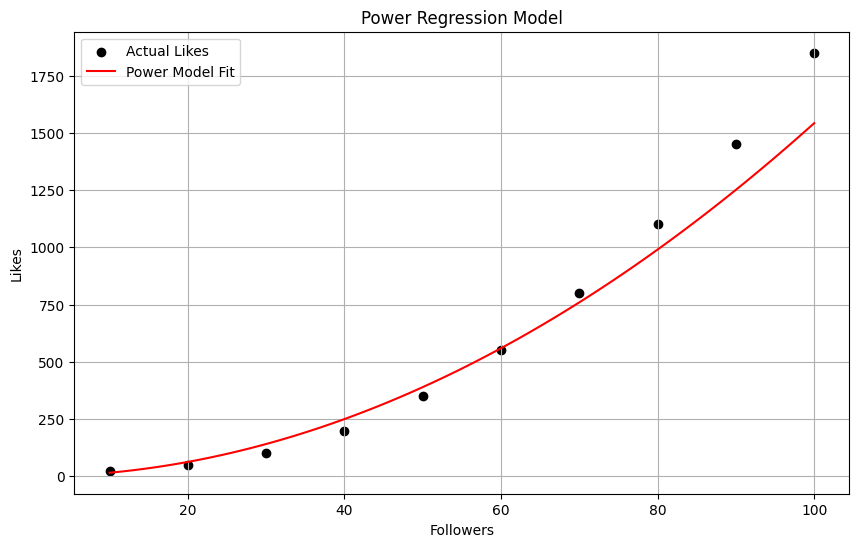

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Followers'], df['Likes'], label="Actual Likes", color="black")
plt.plot(followers_range, pred_likes, label="Power Model Fit", color="red")

plt.xlabel("Followers")
plt.ylabel("Likes")
plt.title("Power Regression Model")
plt.legend()
plt.grid(True)
plt.show()